## 1학기 복습 -연습

### 1.수업을 위한 data  활용을 위해 깃허브 연동하기

In [2]:
!git clone 'https://'github.com/KangKyungHwa/DSMH_2/''

Cloning into 'DSMH_2'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 31 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 472.22 KiB | 4.25 MiB/s, done.
Resolving deltas: 100% (2/2), done.


### 2. 원활한 한글 인식을 위해 폰트 설치

In [3]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 2.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking font

### 3. 나눔고딕 설치

In [4]:
from matplotlib import pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.unicode_minus'] = False

### 4.현재 설치된 폰트 확인

In [5]:
import matplotlib.pyplot as plt

print("현재 Matplotlib 폰트 설정:", plt.rcParams['font.family']) #현재 설치된 폰트 확인


현재 Matplotlib 폰트 설정: ['NanumGothic']


### 5. 깃허브에서 실습데이터 불러오기

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("DSMH_2/8_20/Sleep.csv")
print(df.head(4), '\n\n')
# print(df.tail(4))


   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level  Daily Steps  \
0                 6                       42             6         4200   
1                 6                       60             8        10000   
2                 6                       60             8        10000   
3                 4                       30             8         3000   

  Sleep Disorder  
0            NaN  
1            NaN  
2            NaN  
3    Sleep Apnea   




### 6. 결측치 확인

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           369 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   Daily Steps              374 non-null    int64  
 9   Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(6), object(3)
memory usage: 29.3+ KB
None


### 7. 결측치 확인 및 결측치가 있는 행 찾아보기

In [8]:
print('각 열의 결측치 개수:')
print(df.isnull().sum(), '\n\n')

print('결측치가 있는 행:')
display(df[df.isnull().any(axis=1)])  #결측항목 95,96,97,98,99

각 열의 결측치 개수:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               5
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
Daily Steps                  0
Sleep Disorder             219
dtype: int64 


결측치가 있는 행:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,10000,NaN
7,8,Male,29,Doctor,7.8,7,75,6,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,8000,NaN
...,...,...,...,...,...,...,...,...,...,...
341,342,Female,56,Doctor,8.2,9,90,3,10000,NaN
342,343,Female,56,Doctor,8.2,9,90,3,10000,NaN
343,344,Female,57,Nurse,8.1,9,75,3,7000,NaN
358,359,Female,59,Nurse,8.0,9,75,3,7000,NaN


### 8. Sleep Duration column의 결측치 처리하기

In [9]:
df['Sleep Duration'] = df['Sleep Duration'].fillna(df['Sleep Duration'].mean())  #평균값으로 대체
print(df.head(), '\n\n')
print(df.info())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level  Daily Steps  \
0                 6                       42             6         4200   
1                 6                       60             8        10000   
2                 6                       60             8        10000   
3                 4                       30             8         3000   
4                 4                       30             8         3000   

  Sleep Disorder  
0            NaN  
1            NaN  
2            NaN  
3    Sleep Apnea  
4    Sleep Apnea   


<class 'pandas.core.frame.DataFrame

### 9. 이상치가 있는지 확인해 보기

####*IQR(사분위범위)  복습

**1.사분위 범위**
사분위 범위(interquartile range, IQR)는 통계에서 자료의 산포(흩어짐)를 나타내는 지표로, 데이터의 중간 50%가 분포하는 범위를 의미-->데이터가 중앙부에서 얼마나 퍼져 있는지를 수치로 보여 줌

**2.계산 방법**
사분위 범위는 전체 자료를 크기순으로 정렬한 뒤
하위 25% 지점(Q1)과 상위 25% 지점(Q3) 차이를 계산한다.
예) Q1=20, Q3=40이면 사분위 범위는 20

공식: IQR = Q3 − Q1
제3사분위수(Q3)와 제1사분위수(Q1)의 차이

**3.통계적 의미**
1)사분위 범위는 표준편차와 달리 평균을 기준으로 하지 않기 때문에,
2)극단값이 포함된 분포에서도 안정적인 변동성 척도를 제공
3)탐색적 자료 분석(EDA)에 유용

**4.활용**
박스그림(Box plot)에서 상자 길이로 시각화되며, 이상치 판별에 자주 이용됨 일반적으로 데이터 값이 Q1−1.5×IQR보다 작거나 Q3+1.5×IQR보다 크면 이상치로 간주

### 10. 이상치 처리가 잘 되었는지 확인하기 위해 원본데이터를 복사해서 사용

In [11]:
# 이상치 처리할 데이터 복사하여 사용

df_copy_outlier = df.copy()

### 11. 이상치 처리하기

In [12]:
# 'Physical Activity Level' 컬럼의 사분위수(Q1, Q3)와 IQR  계산

q1 = df_copy_outlier['Physical Activity Level'].quantile(0.25)
q3 = df_copy_outlier['Physical Activity Level'].quantile(0.75)
iqr = q3 - q1
# 또는 IQR = df_copy_outlier["Physical Activity Level"].describe()["75%"]-df_copy_outlier["Physical Activity Level"].describe()["25%"]


# 이상치 판단을 위한 상한선(upper_bound)을 계산합니다.
upper_bound = q3 + 1.5 * iqr

print(f"Q1 (1사분위수): {q1}")
print(f"Q3 (3사분위수): {q3}")
print(f"IQR (사분위 범위): {iqr}")
print(f"이상치 상한선 (Q3 + 1.5 * IQR): {upper_bound}")

Q1 (1사분위수): 45.0
Q3 (3사분위수): 75.0
IQR (사분위 범위): 30.0
이상치 상한선 (Q3 + 1.5 * IQR): 120.0


### 12. 120을 넘는 값은 제외한다

In [13]:
df_out= df_copy_outlier[df_copy_outlier['Physical Activity Level'] <= 120]
print(df_out.head(), '\n\n')
print(df_out.info())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level  Daily Steps  \
0                 6                       42             6         4200   
1                 6                       60             8        10000   
2                 6                       60             8        10000   
3                 4                       30             8         3000   
4                 4                       30             8         3000   

  Sleep Disorder  
0            NaN  
1            NaN  
2            NaN  
3    Sleep Apnea  
4    Sleep Apnea   


<class 'pandas.core.frame.DataFrame

### 13. `df`와 `df_copy_outlier`의 'Physical Activity Level' 박스 플롯 비교

/tmp/ipykernel_625/1754870013.py:15: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_625/1754870013.py:15: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_625/1754870013.py:15: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_625/1754870013.py:15: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_625/1754870013.py:15: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 

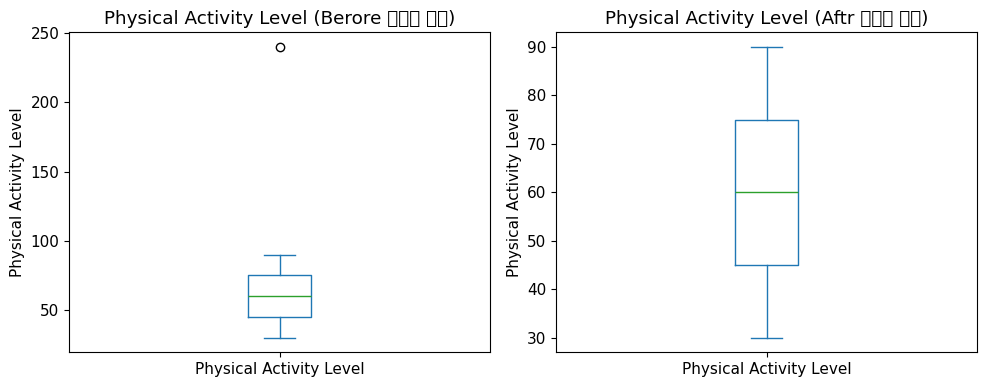

In [14]:
plt.figure(figsize=(10, 4))

# df의 'Physical Activity Level' 박스 플롯 (이상치 제거 후)
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 플롯
df_copy_outlier['Physical Activity Level'].plot(kind='box')
plt.title('Physical Activity Level (Berore 이상치 제거)')
plt.ylabel('Physical Activity Level')

# df'Physical Activity Level' 박스 플롯 (이상치 제거 후)
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 플롯
df_out['Physical Activity Level'].plot(kind='box')
plt.title('Physical Activity Level (Aftr 이상치 제거)')
plt.ylabel('Physical Activity Level')

plt.tight_layout()
plt.show()

### 14. 통합할 데이터 불러오기

In [15]:
df2 = pd.read_csv("DSMH_2/8_20/Health.csv")
print(df2.head(4), '\n\n')

   Person ID BMI Category Blood Pressure  Heart Rate
0          1   Overweight         126/83          77
1          2       Normal         125/80          75
2          3       Normal         125/80          75
3          4        Obese         140/90          85 




 ### 15. 데이터 통합해 보기(데이터 항목 추가)

In [16]:
#  데이터 통합하기
merged_data = pd.merge(df, df2, on='Person ID')
print(merged_data.head(4), '\n\n')
print(merged_data.info())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level  Daily Steps  \
0                 6                       42             6         4200   
1                 6                       60             8        10000   
2                 6                       60             8        10000   
3                 4                       30             8         3000   

  Sleep Disorder BMI Category Blood Pressure  Heart Rate  
0            NaN   Overweight         126/83          77  
1            NaN       Normal         125/80          75  
2            NaN       Normal         125/80          75  
3    Sleep Apnea        Obese         140/90          85 

 ### 16. 시각화: Stress Level과 Quality of Sleep의 산점도 그리기

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

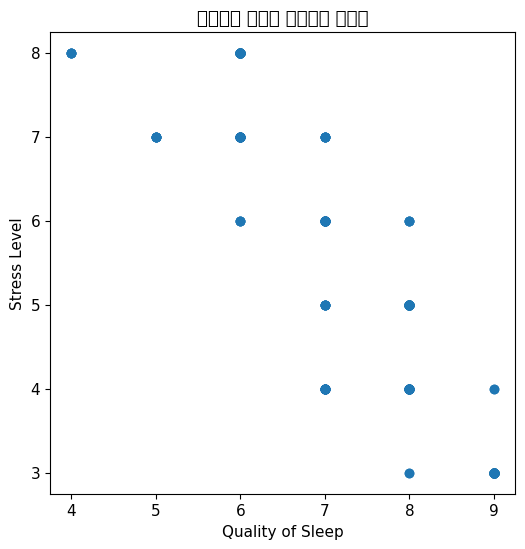

In [17]:
# 󰋓 Stress Level과 Quality of Sleep의 산점도 그리기
plt.scatter(df['Quality of Sleep'],df['Stress Level'])
plt.xlabel('Quality of Sleep')
plt.ylabel('Stress Level')
plt.title('스트레스 수준과 수면시간 산점도')
plt.show()

### 17. Sleep Duration과 BMI Category의 박스 플롯 그리기

<Figure size 1000x600 with 0 Axes>

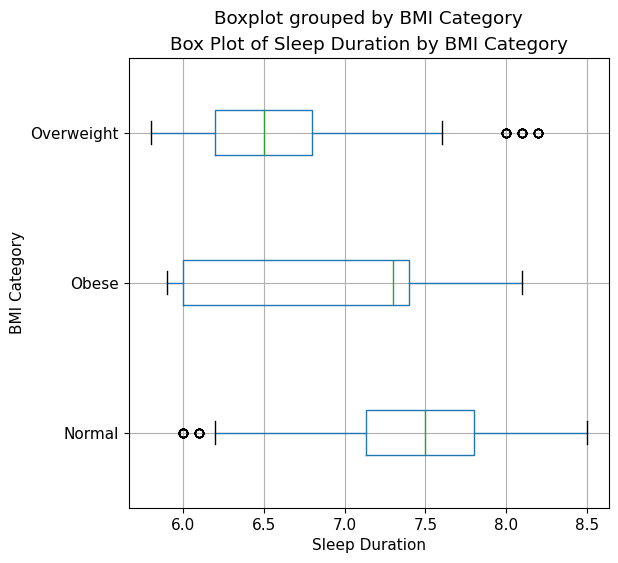

In [18]:
plt.figure(figsize=(10, 6))
merged_data.boxplot(column = 'Sleep Duration', by = 'BMI Category', vert = False)  #수평으로 그리기
plt.xlabel('Sleep Duration')
plt.ylabel('BMI Category')
plt.title('Box Plot of Sleep Duration by BMI Category')
plt.show()